### A4 — Cost Map

  [cache] Loading costmap_A4_1_50m.gpkg from disk (use force_rebuild=True to rebuild)
  [cache] Loading costmap_A4_2_50m.gpkg from disk (use force_rebuild=True to rebuild)


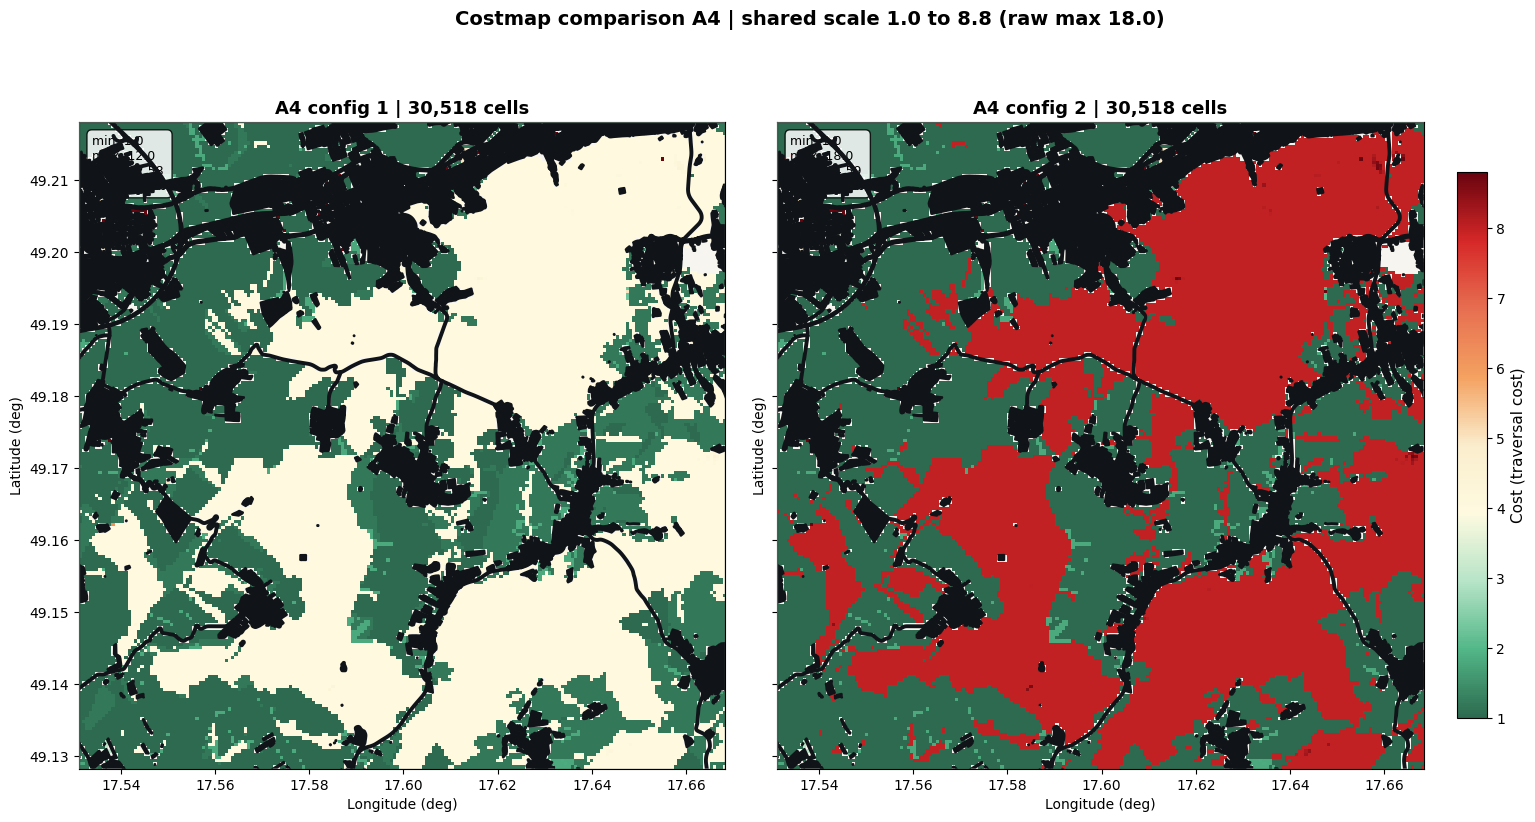

In [1]:
"""
Build and compare two square costmaps for A4.
Each scenario uses its own config module and both outputs share one color scale.
"""

import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

from src.costmap_builder import build_costmaps_for_scenarios
from src.map_plot import plot_costmaps_side_by_side

AREA_LABEL = "A4"
GEOJSON_PATH = Path("../data_A4.geojson")
GPKG_PATH = Path("../data/raw/ZABAGED_RESULTS.gpkg")
OUTPUT_DIR = Path("../data/processed/A4")
CELL_SIZE = 50

SCENARIOS = [
    {"module": "config_costs_A4_1", "label": "A4 config 1", "export_prefix": "costmap_A4_1"},
    {"module": "config_costs_A4_2", "label": "A4 config 2", "export_prefix": "costmap_A4_2"},
]

scenario_results = build_costmaps_for_scenarios(
    SCENARIOS,
    GEOJSON_PATH,
    GPKG_PATH,
    OUTPUT_DIR,
    CELL_SIZE,
)
plot_costmaps_side_by_side(scenario_results, AREA_LABEL)



DIJKSTRA A4 config 1
Start coord: (17.54, 49.14) -> square cell_id=4690
Goal  coord: (17.65, 49.21) -> square cell_id=28494
Start and Goal are outside exclusion zones.
  [A4 config 1] Building graph (30,518 nodes)... 114,402 direct + 510,604 jump edges (4,908 blocked by can_cross) (17.3 s)
  [A4 config 1] Turn penalty active: 9 dirs x 11 jumps = 3,021,282 states (~49 MB)
  [A4 config 1] Running Dijkstra (3,021,282 states)... 2,424,648 expansions (141.3 s)
Total cost: 643.2 | 219 cells | ~13,428 m | jumps: 3x | turns: 8 | 159.12 s total

DIJKSTRA A4 config 2
Start coord: (17.54, 49.14) -> square cell_id=4690
Goal  coord: (17.65, 49.21) -> square cell_id=28494
Start and Goal are outside exclusion zones.
  [A4 config 2] Building graph (30,518 nodes)... 114,402 direct + 510,604 jump edges (4,908 blocked by can_cross) (18.5 s)
  [A4 config 2] Turn penalty active: 9 dirs x 11 jumps = 3,021,282 states (~49 MB)
  [A4 config 2] Running Dijkstra (3,021,282 states)... 2,390,378 expansions (136.8

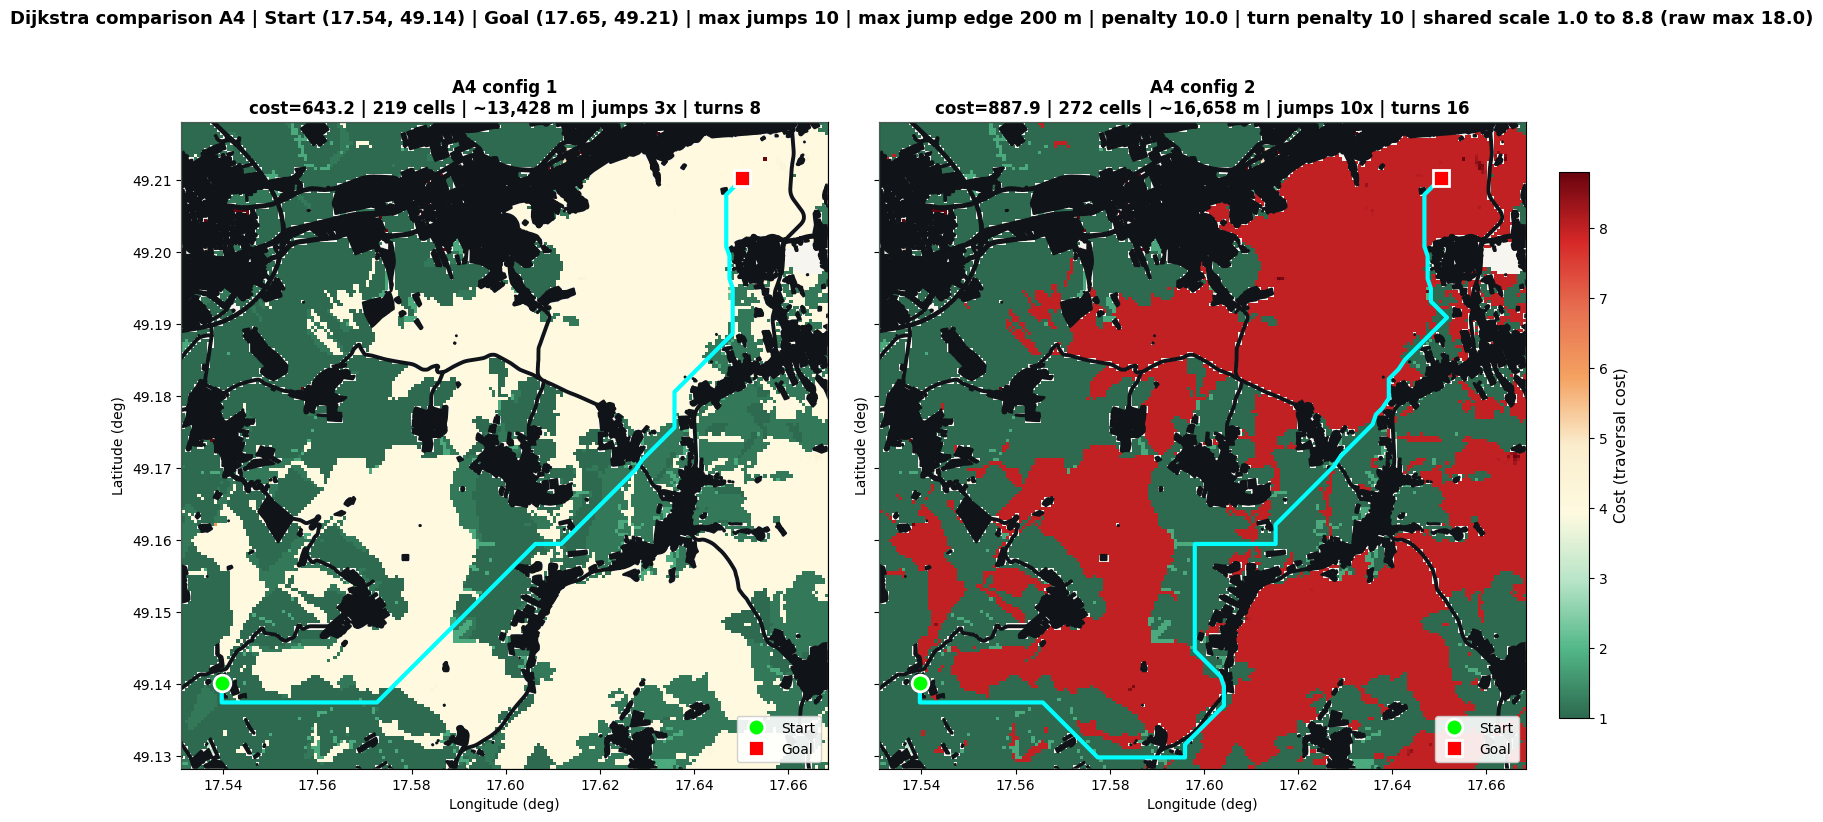

In [2]:
"""
Run and compare Dijkstra on both A4 costmaps.
Both scenarios use the same start/goal and shared visualization scaling.
"""

from src.dijkstra import run_dijkstra_for_scenarios
from src.map_plot import plot_dijkstra_side_by_side

START_LONLAT = (17.54, 49.14)
GOAL_LONLAT = (17.65, 49.21)

EXCLUSION_PENALTY = 10.0
MAX_JUMPS = 10
MAX_JUMP_EDGE_M = 200.0
TURN_PENALTY = 10

route_results = run_dijkstra_for_scenarios(
    scenario_results,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)

plot_dijkstra_side_by_side(
    route_results,
    AREA_LABEL,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)


In [3]:
"""
PPO block - inference on the 50 m costmap with forced coarse steps.
Each action moves ~300 m (virtual 8-directional coarse grid) to reduce zigzagging.
Uses route_results from block 3 (same start/goal, same 50 m costmap).
"""
import importlib
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

import ppo_routing_cnn  # noqa: F401 – required so MaskablePPO can deserialise the saved model
import src.ppo_inference as ppo_inference

importlib.reload(ppo_inference)

AREA_LABEL = globals().get("AREA_LABEL", "A4")
EXCLUSION_PENALTY = globals().get("EXCLUSION_PENALTY", 10)
MAX_JUMPS = globals().get("MAX_JUMPS", 10)
TURN_PENALTY = globals().get("TURN_PENALTY", 1.0)

MODEL_PATH = Path("../ppo_models/coarse300_12km_v4/ppo_routing_final")
PPO_SAMPLE_COUNT = 2
PPO_MAX_ATTEMPTS = 50
PPO_MAX_STEPS = 200
COARSE_STEP_M = 300

ppo_sample_results = ppo_inference.run_ppo_samples_for_scenarios(
    route_results,
    model_path=MODEL_PATH,
    n_samples=PPO_SAMPLE_COUNT,
    max_attempts=PPO_MAX_ATTEMPTS,
    exclusion_penalty=EXCLUSION_PENALTY,
    max_jumps=MAX_JUMPS,
    turn_penalty=TURN_PENALTY,
    max_steps=PPO_MAX_STEPS,
    coarse_step_m=COARSE_STEP_M,
)


  [A4 config 1] Building coarse graph (300 m steps)...
  Coarse graph (300 m): 30416/30518 nodes reachable, avg 7.1 directions/node
  Detected torch.compile() artifact - remapping _orig_mod keys...
  [A4 config 1 attempt 1] PPO: FAILED to reach goal in 200 steps (1.64s)
  [A4 config 1 attempt 2] PPO: FAILED to reach goal in 200 steps (1.09s)
  [A4 config 1 attempt 3] PPO: FAILED to reach goal in 200 steps (1.16s)
  [A4 config 1 attempt 4] PPO: FAILED to reach goal in 200 steps (1.06s)
  [A4 config 1 attempt 5] PPO: FAILED to reach goal in 200 steps (1.10s)
  [A4 config 1 attempt 6] PPO: FAILED to reach goal in 200 steps (1.06s)
  [A4 config 1 attempt 7] PPO: FAILED to reach goal in 181 steps (1.06s)
  [A4 config 1 attempt 8] PPO: FAILED to reach goal in 200 steps (1.05s)
  [A4 config 1 attempt 9] PPO: FAILED to reach goal in 55 steps (0.35s)
  [A4 config 1 attempt 10] PPO: FAILED to reach goal in 200 steps (1.25s)
  [A4 config 1 attempt 11] PPO: FAILED to reach goal in 200 steps (1.09s

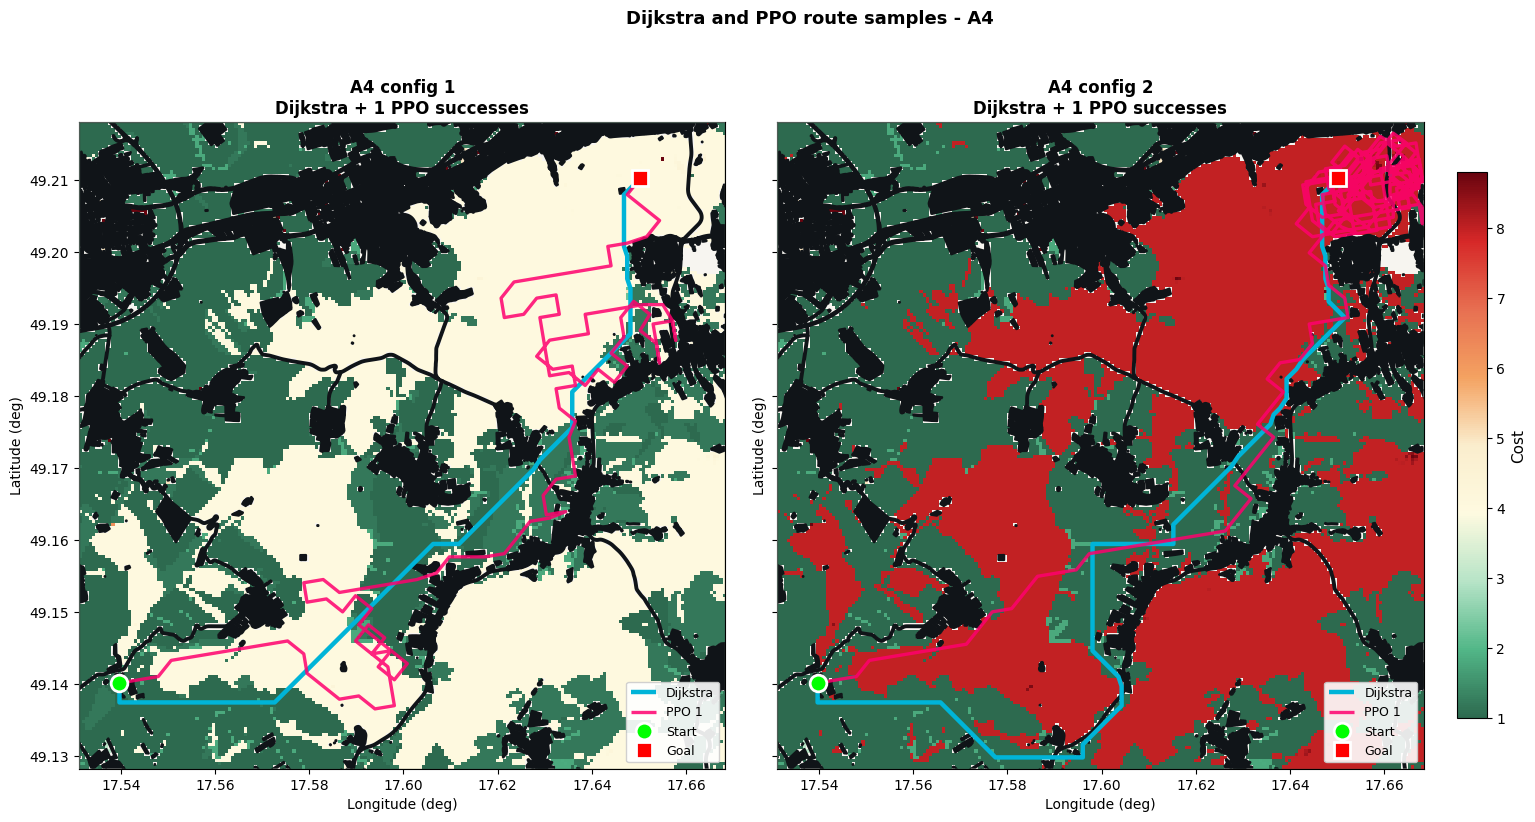

In [4]:
import src.ppo_visualization as ppo_visualization

ppo_visualization.plot_dijkstra_with_ppo_samples(
    ppo_sample_results,
    AREA_LABEL,
    START_LONLAT,
    GOAL_LONLAT,
)
